# COMP3008 CW2

You have been provided with data from the UK Annual Population Survey from January 2019 to December 2024 in two separate csv files. The UK government wants to understand how the COVID-19 pandemic has impacted employment patterns and regional economies.

To do this you need to use a range of big data analysis techniques. The report should contain commentary on the results of each of the analysis techniques you apply to the data and your final insights and recommendations, with justification.

Your report should include how the data has been pre-processed, at least three different methods for exploratory analysis and at least two methods for predictive modelling, where you need to comment on the suitability and accuracy of each of the methods. 

## Report Requirements

- You should write your report so that it is understandable and accessible, you can assume the reader is familiar with the COMP3008 material and do not wish to see it reiterated in your report.
- Your report should provide details of the methods applied for the predictive modelling.
- Your work on this assignment should involve considerable reading and research from multiple appropriate sources—the Internet is a good place to start, but do not stop there; consider also books and preferably academic articles. Include a reference list, and make sure that your report contains citations to the sources in your reference list and using Harvard style referencing.
- When citing sources, ensure that you provide clear and explicit information about the contents of the cited source, so that the relationship between the contents of the source and the points being made are clear

The length of the report should be 3500 words (+/-10%). Include a word count immediately after your report title - *a penalty of 5 marks will be applied for omitting the word count*. Reports exceeding the maximum word length will be penalised. Your reference list is not included in the word count. If you produce appendices, these are not included in the word count. 

## Assessment Criteria

- Literature review (10 Marks)
- Overview of the methods used in report (10 Marks)
- Pre-processing of the data (10 Marks)
- Application of the methods (20 Marks)
- Results (10 Marks)
- Conclusion (5 Marks)
- Reference list (5 Marks)

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [101]:
df_early = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2019_Dec2021.csv")
df_late = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2022_Dec2024.csv")

C:\Users\richa\AppData\Local\Temp\ipykernel_39272\3494456411.py:1: DtypeWarning: Columns (39,434) have mixed types. Specify dtype option on import or set low_memory=False.
  df_early = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2019_Dec2021.csv")
C:\Users\richa\AppData\Local\Temp\ipykernel_39272\3494456411.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_late = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2022_Dec2024.csv")


## Data Pre-Processing

`AnnualPopulationSurvey_Jan2019_Dec2021.csv` uses `fileyear`, `AnnualPopulationSurvey_Jan2022_Dec2024.csv` uses `FILEYEAR`. All column names should be standardised to uppercase.

> Done before combining to prevent duplicate column names

In [102]:
df_early.columns = df_early.columns.str.upper()
df_late.columns = df_late.columns.str.upper()

In [103]:
df_combined = pd.concat([ df_early, df_late ], ignore_index=True)

In [104]:
print(f"Records (Early/Late): { df_early.shape[0] }/{ df_late.shape[0] }") # Not equal datasets
print(f"Columns (Early/Late): { len(df_early.columns) }/{ len(df_late.columns) }\n")

print(f"Total Records Combined: { df_combined.shape[0] }")
print(f"Total Columns Combined: { len(df_combined.columns) }\n")

print(f"Head:\n { df_combined.head()}")
print(f"Described:\n { df_combined.describe() }")

Records (Early/Late): 430347/320589
Columns (Early/Late): 526/473

Total Records Combined: 750936
Total Columns Combined: 550

Head:
    AAGE  ACTHR  ACTHR2  ACTPOT  ACTUOT  ACTWKDY1  ACTWKDY2  ACTWKDY3  \
0    13    NaN     NaN     NaN     NaN       NaN       NaN       NaN   
1    13    NaN     NaN     NaN     NaN       NaN       NaN       NaN   
2    13    NaN     NaN     NaN     NaN       NaN       NaN       NaN   
3    11    NaN     NaN     NaN     NaN       1.0       3.0       2.0   
4    13   40.0     NaN     0.0     0.0       7.0       1.0       2.0   

   ACTWKDY4  ACTWKDY5  ...  GOR9DCENSUS2021  HIQUAL22  HIQUL22D  \
0       NaN       NaN  ...              NaN       NaN       NaN   
1       NaN       NaN  ...              NaN       NaN       NaN   
2       NaN       NaN  ...              NaN       NaN       NaN   
3       4.0       NaN  ...              NaN       NaN       NaN   
4       3.0       NaN  ...              NaN       NaN       NaN   

   ITL221CENSUS2021  ITL225CEN

---

```
Value = -9.0
Value = -8.0
```

Population Survey data uses specific codes for missing data; need to handle these during pre-processing.

In [105]:
df_combined.replace([ -8.0, -9.0 ], np.nan, inplace=True)

750,000+ records would be overwhelming to plot individually; instead they will be grouped by a time period to reveal trends.

- `REFDTE` Reference date
- `REFWKD` Reference week day
- `REFWKM` Reference week month
- `REFWKY` Reference week year
- `QRTR` Quarter

> https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.to_period.html <br>
> https://pandas.pydata.org/docs/reference/api/pandas.PeriodIndex.html

In [106]:
# print(f"Unique fileyears: {df_combined["fileyear"].unique()}")
# print(f"Missing fileyears: {df_combined["fileyear"].isna().sum()}") # 320,589; implies fileyear completely missing from df_late

print([col for col in df_combined.columns if "YEAR" in col]) # ["FILEYEAR", "FILEYEAR"] duplicate?

# df_late has FILEYEAR, are column names case-sensitive?
print(f"Unique fileyears: {df_combined["FILEYEAR"].unique()}") # appears so
print(f"Missing fileyears: {df_combined["FILEYEAR"].isna().sum()}")

print(f"Unique Quarters: {df_combined["QRTR"].unique()}")

['FILEYEAR']
Unique fileyears: [2020 2021 2019 2022 2024 2023]
Missing fileyears: 0
Unique Quarters: [1 2 4 3]


In [107]:
df_combined["QUARTER_PERIOD"] = df_combined["FILEYEAR"].astype(int).astype(str) + "Q" + df_combined["QRTR"].astype(int).astype(str)

df_combined["MONTH_STR"] = df_combined["REFWKY"].astype(int).astype(str) + "-" + df_combined["REFWKM"].astype(int).astype(str).str.zfill(2) + "-01"
df_combined["MONTHLY_PERIOD"] = pd.to_datetime(df_combined["MONTH_STR"]).dt.to_period("M")

df_combined = df_combined.sort_values("MONTHLY_PERIOD")

# IF sorted by Monthly Periods, Quarter Periods will be inherently sorted
print(f"Quarter Periods: {df_combined["QUARTER_PERIOD"].unique()}")
print(f"Monthly Periods: {df_combined["MONTHLY_PERIOD"].unique()}") # looks sorted yay


Quarter Periods: ['2019Q1' '2019Q2' '2019Q3' '2019Q4' '2020Q1' '2020Q2' '2020Q3' '2020Q4'
 '2021Q1' '2021Q2' '2021Q3' '2021Q4' '2022Q1' '2022Q2' '2022Q3' '2022Q4'
 '2023Q1' '2023Q2' '2023Q3' '2023Q4' '2024Q1' '2024Q2' '2024Q3' '2024Q4']
Monthly Periods: <PeriodArray>
['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07',
 '2019-08', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02',
 '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09',
 '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04',
 '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11',
 '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06',
 '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01',
 '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08',
 '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03',
 '2024-04', '2024-05', '2024-0

In [108]:
# 2019-2022 -> HIQUL15D
# 2022-2024 -> HIQUL22D
# Needs to be merged
df_combined["HIQUL_Unified"] = df_combined["HIQUL22D"].fillna(df_combined["HIQUL15D"])

# Heatmap

A heatmap will display which variables have the highest influence on results, and which variables are correlated. If variables are very strongly linked, this can be used to inform PCA decisions and identify and drop redundant variables (co-linearity) improving the computational efficiency of the model analysis.

In [109]:
heatmap_components = [
    "AAGE", "ACTHR", "GRSSWK", "HOURPAY", "AGE", "BUSHR", "TOTAC1", "USUHR", "FILEYEAR", "QRTR"
]

df_heatmap = df_combined[heatmap_components].copy()

correlation_matrix = df_heatmap.corr()


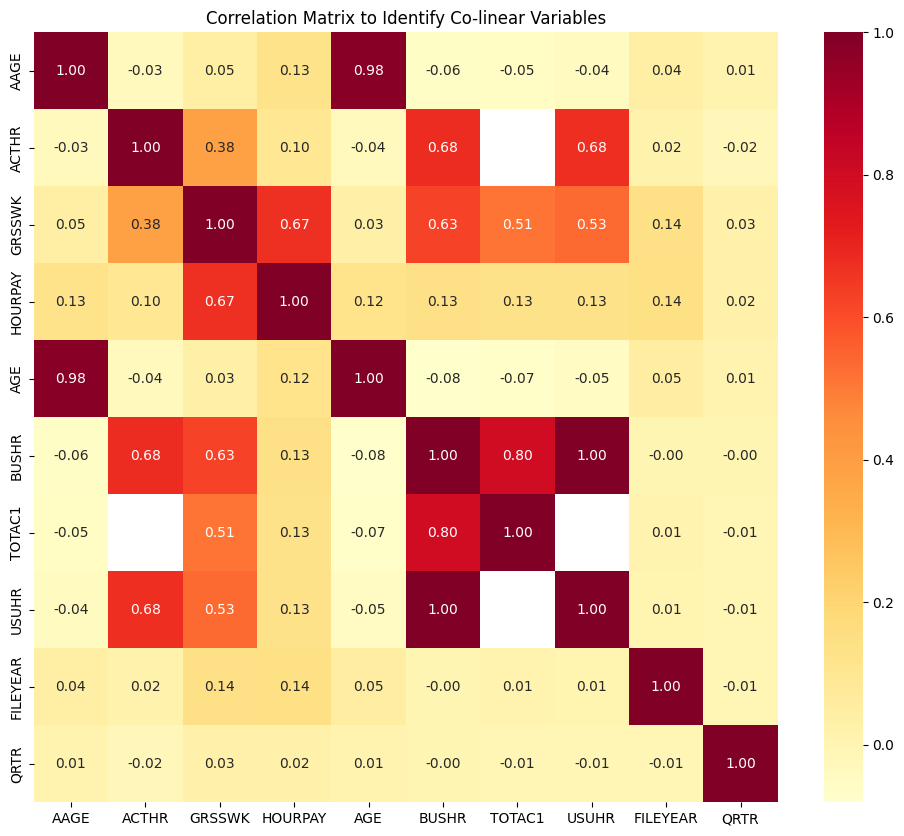

In [110]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Correlation Matrix to Identify Co-linear Variables")

plt.savefig("graphs/correlation_matrix.png", dpi=300)
plt.show()

## Time-Series Analysis: Employment Patterns

Used to visualise how the pandemic has impacted employment patterns.

In [111]:
quarterly_trend_data = df_combined.groupby("QUARTER_PERIOD").agg({
    "ACTHR": "mean",
    "GRSSWK": "mean"
}).reset_index()

quarterly_trend_data["QUARTER_STR"] = quarterly_trend_data["QUARTER_PERIOD"].astype(str)

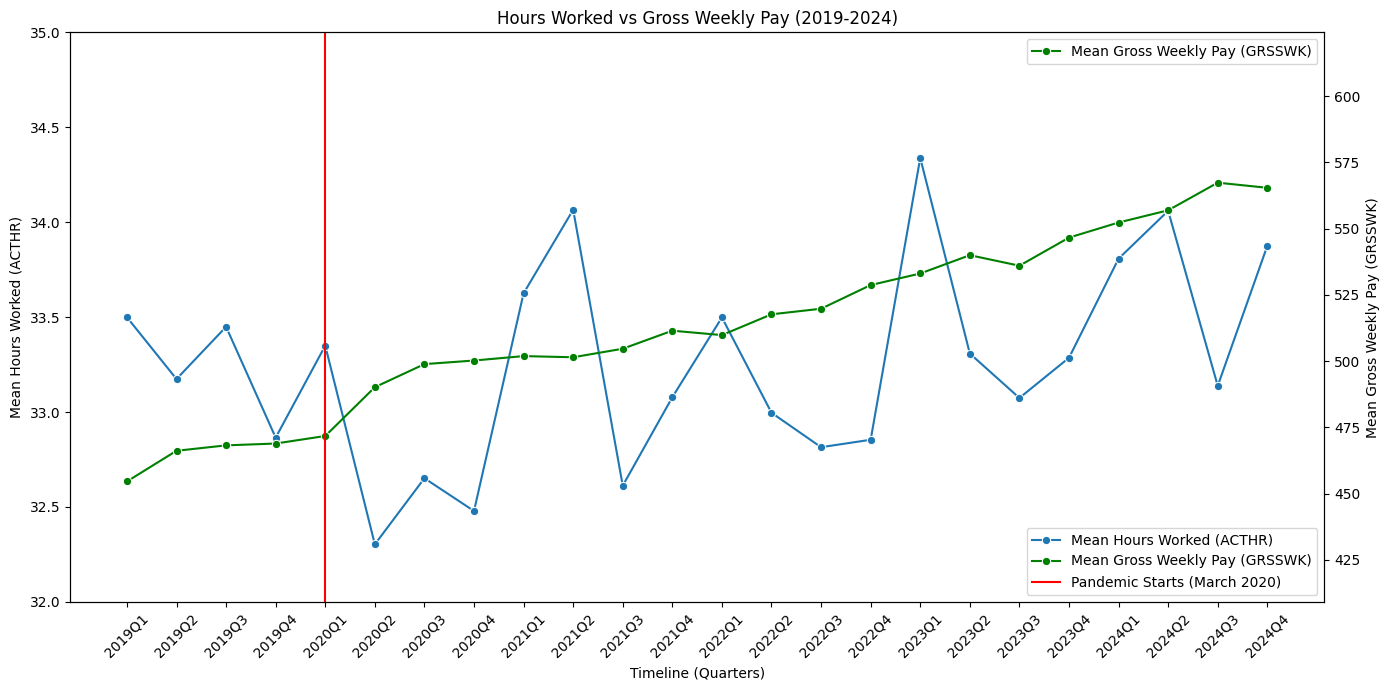

In [112]:
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=quarterly_trend_data, 
             x="QUARTER_STR", 
             y="ACTHR", 
             marker="o", 
             label="Mean Hours Worked (ACTHR)", 
             ax=ax1
)

plt.xticks(rotation=45)
ax1.set_xlabel("Timeline (Quarters)")
ax1.set_ylabel("Mean Hours Worked (ACTHR)")
ax1.set_ylim(32, 35)

ax2 = ax1.twinx()
sns.lineplot(data=quarterly_trend_data, 
             x="QUARTER_STR", 
             y="GRSSWK", 
             marker="o", 
             label="Mean Gross Weekly Pay (GRSSWK)", 
             ax=ax2,
             color="green"
)

# ax2.set_xlabel("Timeline (Quarters)")
ax2.set_ylabel("Mean Gross Weekly Pay (GRSSWK)")
ax2.set_ylim(quarterly_trend_data["GRSSWK"].min() * 0.9, quarterly_trend_data["GRSSWK"].max() * 1.1)

plt.axvline(x="2020Q1", color="red", label="Pandemic Starts (March 2020)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("Hours Worked vs Gross Weekly Pay (2019-2024)")
plt.tight_layout()
plt.savefig("graphs/time_series_acthr_vs_grsswk.png", dpi=300)
plt.show()

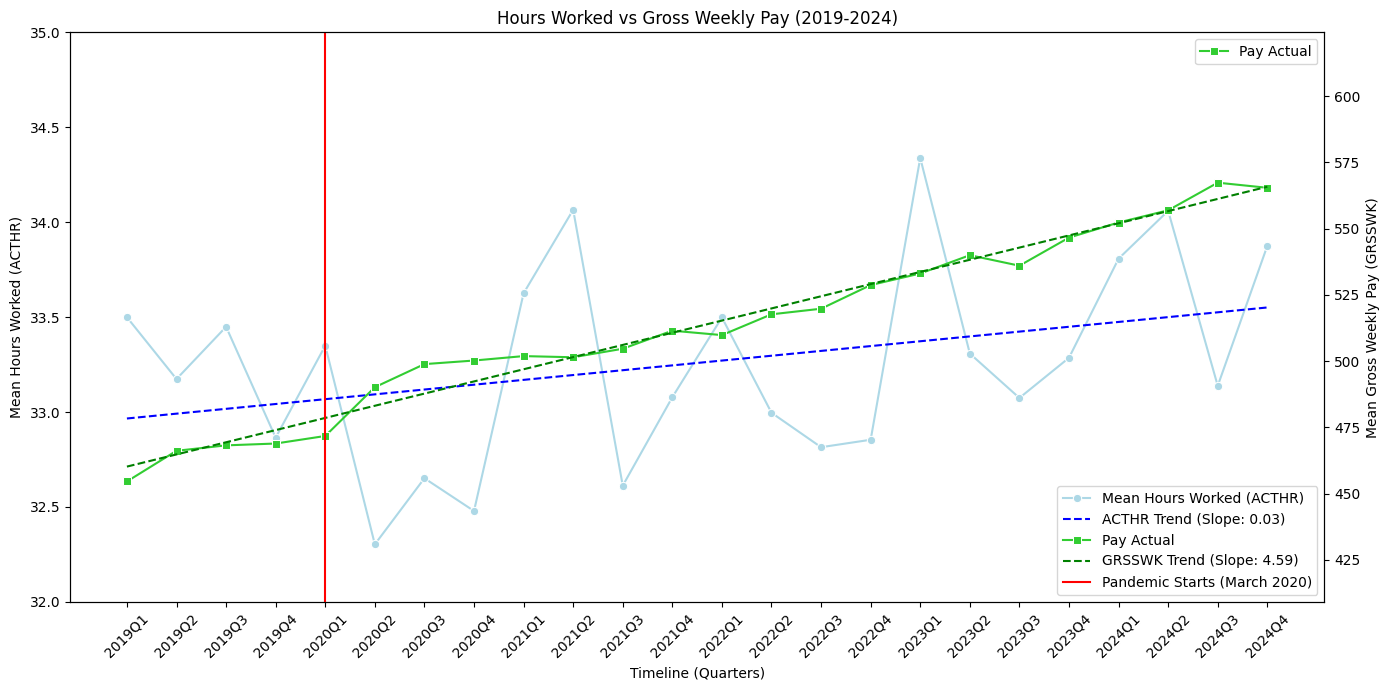

In [113]:
x_series = np.arange(len(quarterly_trend_data))
y_acthr = quarterly_trend_data["ACTHR"]
y_grsswk = quarterly_trend_data["GRSSWK"]

slope_acthr, intercept_acthr = np.polyfit(x_series, y_acthr, 1)
trendline_acthr = slope_acthr * x_series + intercept_acthr

slope_grsswk, intercept_grsswk = np.polyfit(x_series, y_grsswk, 1)
trendline_grsswk = slope_grsswk * x_series + intercept_grsswk

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=quarterly_trend_data,
             x="QUARTER_STR",
             y="ACTHR",
             marker="o",
             ax=ax1,
             label="Mean Hours Worked (ACTHR)",
             color="lightblue"
)
ax1.plot(quarterly_trend_data["QUARTER_STR"], 
         trendline_acthr, 
         label=f"ACTHR Trend (Slope: {slope_acthr:.2f})",
         color="blue", 
         linestyle="--"
)

plt.xticks(rotation=45)
ax1.set_xlabel("Timeline (Quarters)")
ax1.set_ylabel("Mean Hours Worked (ACTHR)")
ax1.set_ylim(32, 35)

ax2 = ax1.twinx()
sns.lineplot(data=quarterly_trend_data, 
             x="QUARTER_STR", 
             y="GRSSWK", 
             marker="s", 
             ax=ax2, 
             label="Pay Actual",
             color="limegreen"
)
ax2.plot(quarterly_trend_data["QUARTER_STR"], 
         trendline_grsswk, 
         label=f"GRSSWK Trend (Slope: {slope_grsswk:.2f})", 
         color="green", 
         linestyle="--"
)

ax2.set_ylabel("Mean Gross Weekly Pay (GRSSWK)")
ax2.set_ylim(y_grsswk.min() * 0.9, y_grsswk.max() * 1.1)

plt.axvline(x="2020Q1", color="red", label="Pandemic Starts (March 2020)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("Hours Worked vs Gross Weekly Pay (2019-2024)")

plt.tight_layout()
plt.savefig("graphs/time_series_acthr_vs_grsswk_trendlines.png", dpi=300)
plt.show()

In [114]:
mean_acthr = quarterly_trend_data["ACTHR"].mean()
mean_grsswk = quarterly_trend_data["GRSSWK"].mean()

norm_slope_acthr = (slope_acthr / mean_acthr) * 100
norm_slope_grsswk = (slope_grsswk / mean_grsswk) * 100

print(f"ACTHR % Growth per Quarter: {norm_slope_acthr:.3f}%")
print(f"GRSSWK % Growth per Quarter: {norm_slope_grsswk:.3f}%")

ACTHR % Growth per Quarter: 0.076%
GRSSWK % Growth per Quarter: 0.895%


In [115]:
monthly_trend_data = df_combined.groupby("MONTHLY_PERIOD").agg({
    "ACTHR": "mean",
    "GRSSWK": "mean"
}).reset_index()

monthly_trend_data["MONTH_STR"] = monthly_trend_data["MONTHLY_PERIOD"].astype(str)

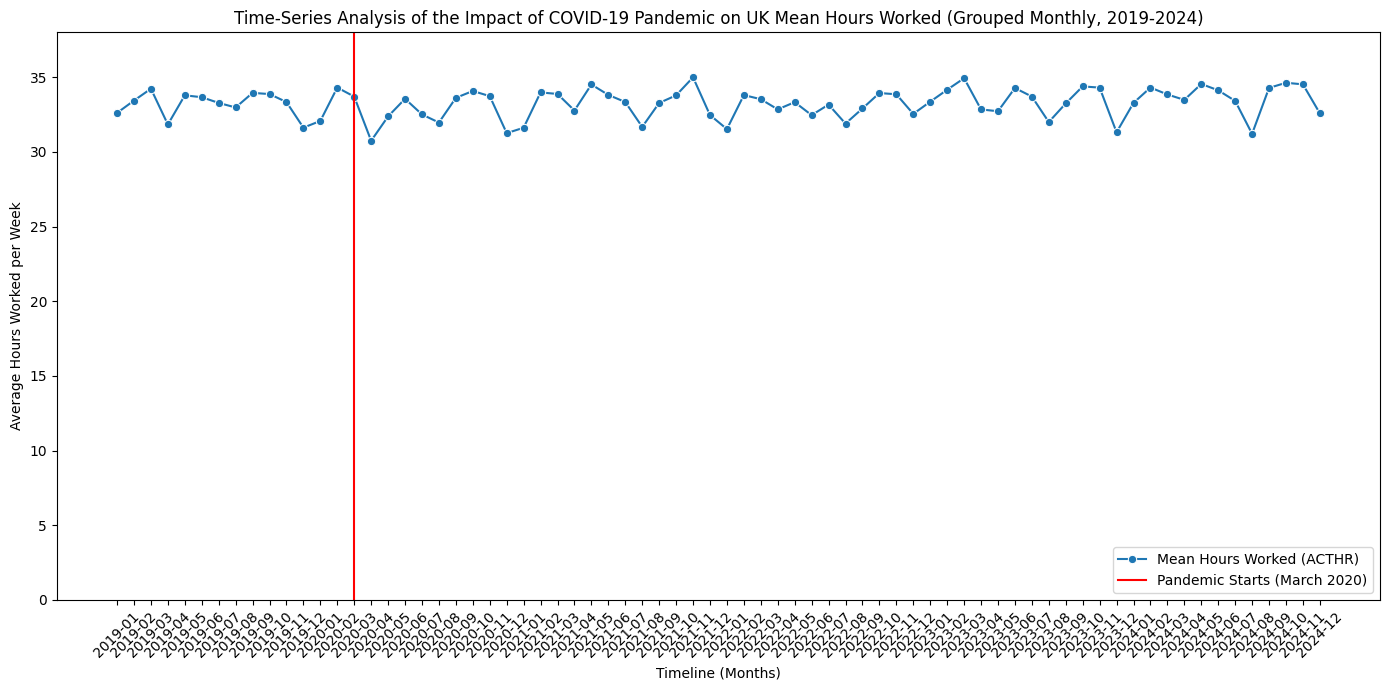

In [116]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=monthly_trend_data,
             x="MONTH_STR",
             y="ACTHR",
             marker="o",
             label="Mean Hours Worked (ACTHR)"
)

plt.axvline(x="2020-03", color="red", label="Pandemic Starts (March 2020)")

plt.title("Time-Series Analysis of the Impact of COVID-19 Pandemic on UK Mean Hours Worked (Grouped Monthly, 2019-2024)")

plt.xlabel("Timeline (Months)")
plt.xticks(rotation=45)

plt.ylabel("Average Hours Worked per Week")
plt.ylim(0, 38)

plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("graphs/time_series_lineplot_hours_worked_by_month.png", dpi=300)
plt.show()

## Regional Impacts

A comparison of `COUNTRY` against `ACTHR` (Actual Hours (excluding overtime))

In [117]:
country_map = {
    1: "England",
    2: "Wales",
    3: "Scotland",
    4: "Scotland North of Caledonian Canal",
    5: "Northern Ireland"
}

country_map_scottish_combined = {
    **country_map,
    4: "Scotland"
}

df_combined["COUNTRY_NAME"] = df_combined["COUNTRY"].map(country_map)
df_combined["COUNTRY_NAME_SCOTTISH_COMBINED"] = df_combined["COUNTRY"].map(country_map_scottish_combined)

In [118]:
all_regions = sorted(df_combined["COUNTRY_NAME"].dropna().unique())
palette = dict(zip(all_regions, sns.color_palette("husl", len(all_regions))))

In [119]:
# Apply mask to outlier datapoint
mask = (df_combined["COUNTRY_NAME"] == "Scotland North of Caledonian Canal") & (df_combined["QUARTER_PERIOD"] == "2024Q4")
df_combined.loc[mask, "ACTHR"] = np.nan

In [120]:
raw_scottish = df_combined.groupby(["QUARTER_PERIOD", "COUNTRY_NAME"])["ACTHR"].mean().unstack()
comb_scottish = df_combined.groupby(["QUARTER_PERIOD", "COUNTRY_NAME_SCOTTISH_COMBINED"])["ACTHR"].mean().unstack()

# X-axis labels:
x_labels = raw_scottish.index.astype(str)

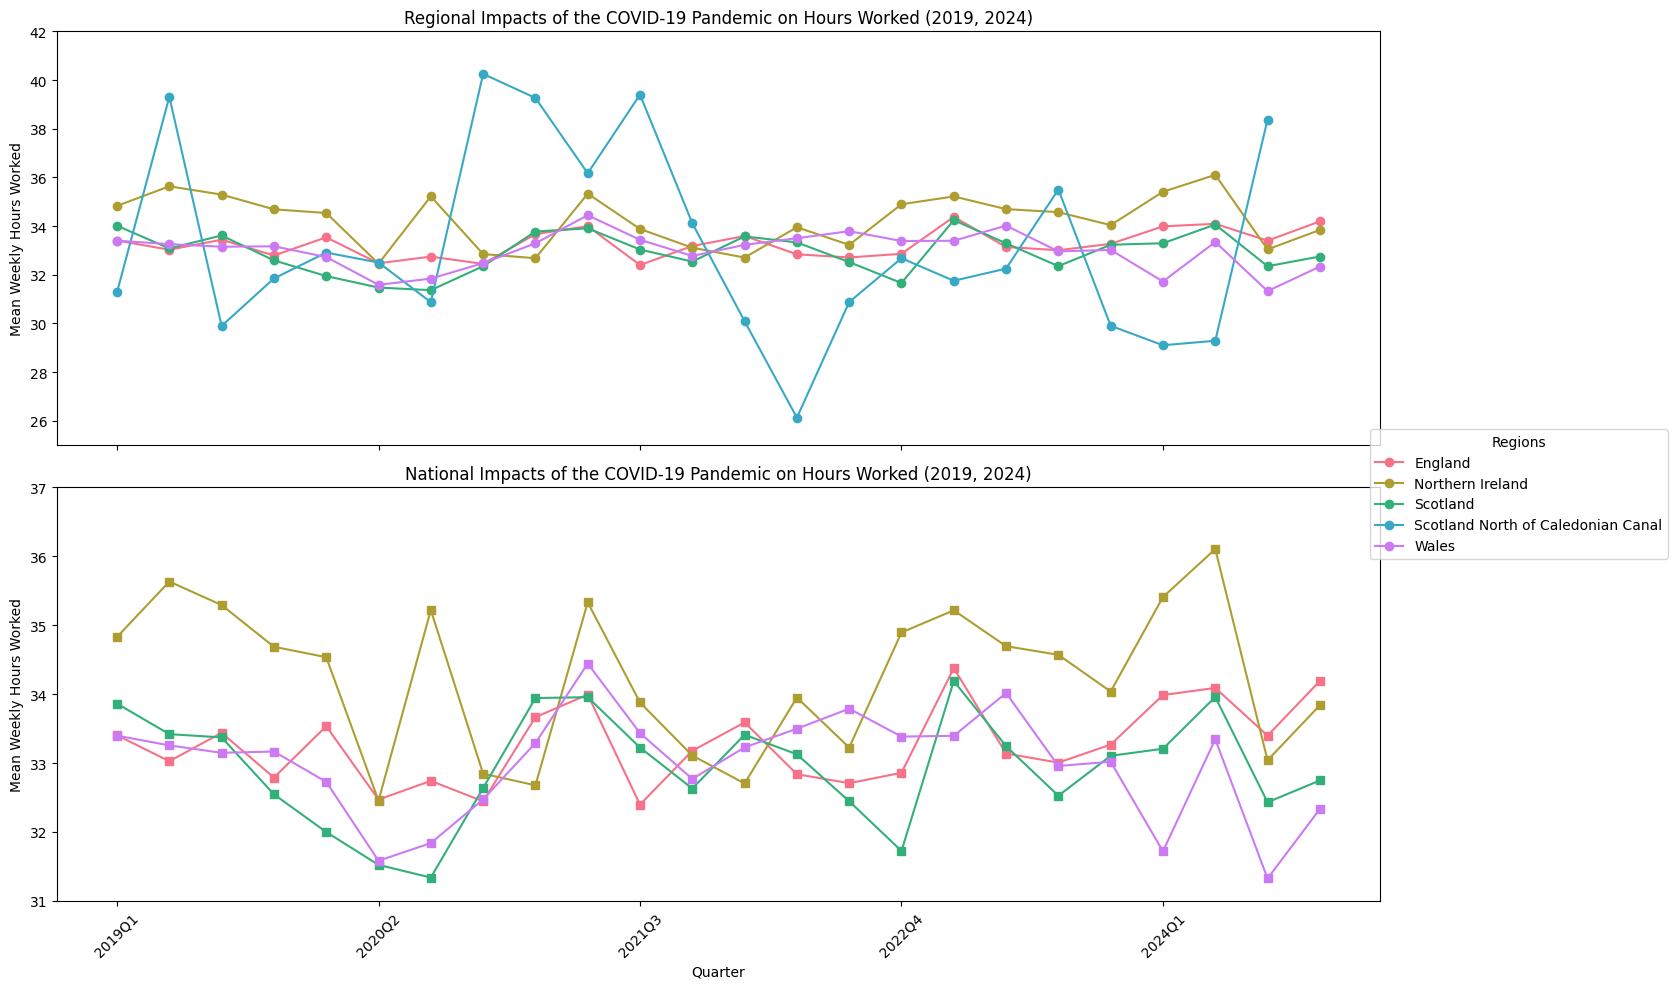

In [121]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

raw_scottish.plot(
    ax=ax1, 
    marker="o", 
    color=[palette.get(c) for c in raw_scottish.columns], 
    legend=False
)

ax1.set_title("Regional Impacts of the COVID-19 Pandemic on Hours Worked (2019, 2024)")

ax1.set_ylabel("Mean Weekly Hours Worked")
ax1.set_ylim(25, 42)

comb_scottish.plot(
    ax=ax2, 
    marker="s", 
    color=[palette.get(c) for c in comb_scottish.columns], 
    legend=False
)

ax2.set_title("National Impacts of the COVID-19 Pandemic on Hours Worked (2019, 2024)")

ax2.set_ylabel("Mean Weekly Hours Worked")
ax2.set_ylim(31, 37)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Regions", bbox_to_anchor=(1.2, 0.5))

plt.xlabel("Quarter")
plt.xticks(rotation=45)

plt.subplots_adjust(right=0.85)
plt.tight_layout()

plt.savefig("graphs/regional_impacts_masked.png", dpi=300, bbox_inches="tight")
plt.show()

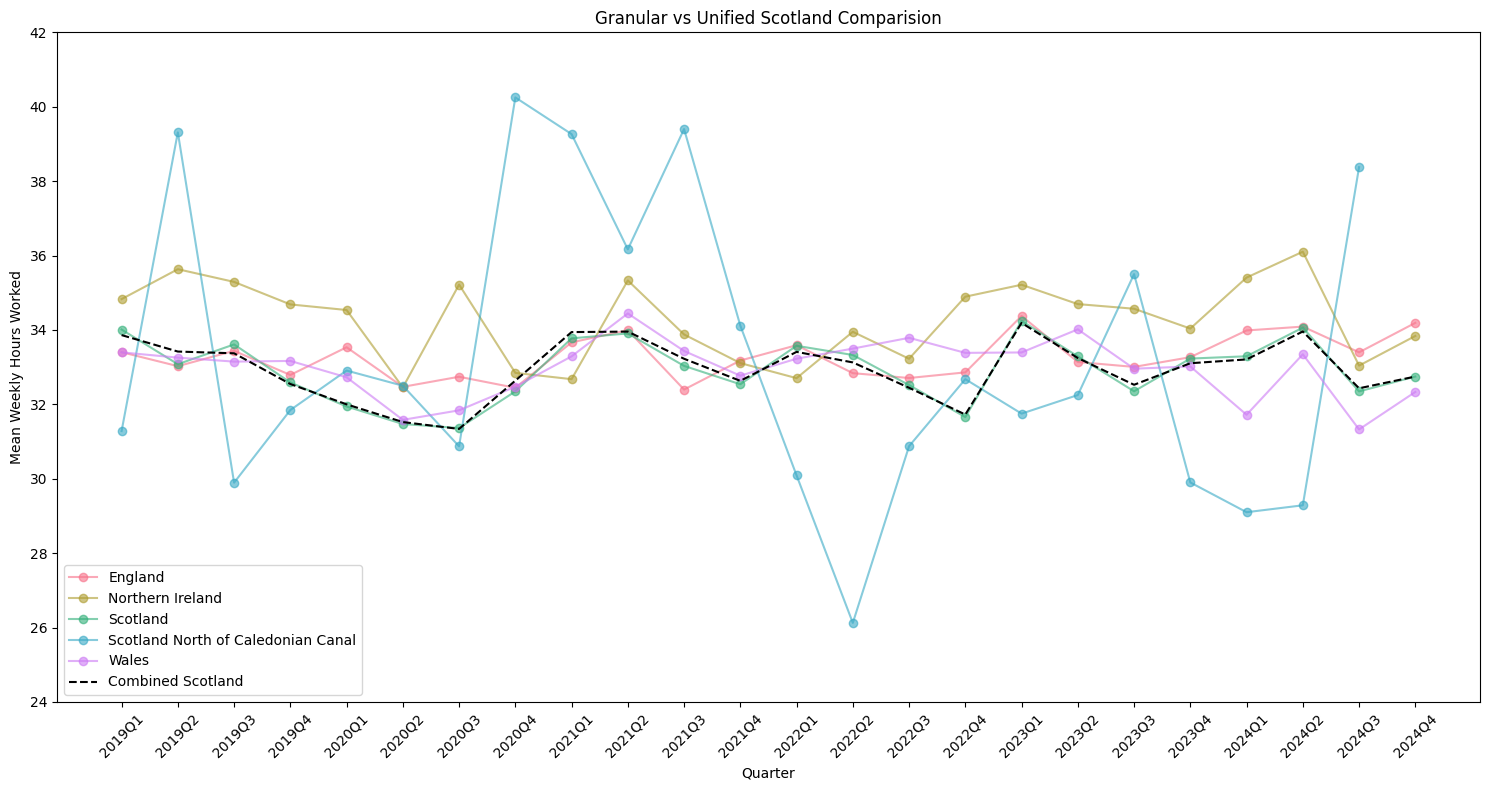

In [122]:
plt.figure(figsize=(15, 8))

for column in raw_scottish.columns:
    plt.plot(
        x_labels, 
        raw_scottish[column].values, 
        marker="o", 
        label=column,
        color=palette.get(column),
        alpha=0.6
    )
    
plt.plot(
    x_labels, 
    comb_scottish["Scotland"].values, 
    color="black", 
    label="Combined Scotland",
    linestyle="--"
)

plt.title("Granular vs Unified Scotland Comparision")
plt.xlabel("Quarter")

plt.ylabel("Mean Weekly Hours Worked")

plt.legend(loc="lower left")

plt.xticks(rotation=45)
plt.ylim(24, 42)

plt.tight_layout()

plt.savefig("graphs/regional_impacts_scottish_comparison.png", dpi=300)
plt.show()



## Predictive Modelling

Linear Regression
- Predict Gross Weekly Pay `GRSSWK`

Random Forest Classifier
- Predict Basic Economic Activity Status `INECAC05`

### Linear Regression

In [149]:
wide_features = ["GRSSWK", "AAGE", "ACTHR", "EDAGEBAND", "EMPLEN", "FTPTW", "HIQUL22D", "MANAGER", "MPNR02", "NSECM20", "POTHR", "PUBLICR", "TOTAC2", "SC20MMJ", "SEX", "SNGDEGB" ]

df_wide = df_combined[wide_features].dropna()
df_wide = pd.get_dummies(df_wide, columns=["EDAGEBAND", "FTPTW", "HIQUL22D", "MANAGER", "NSECM20", "PUBLICR", "SC20MMJ", "SEX", "SNGDEGB"], drop_first=True)
# Feature (X)
# Target  (y)
X_wide = df_wide.drop("GRSSWK", axis=1)
y_wide = df_wide["GRSSWK"]

X_train, X_test, y_train, y_test = train_test_split(X_wide, y_wide, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score:             {r2:.2f}")

Mean Absolute Error: 85.34
R2 Score:             0.51


      Feature  Grouped_Impact
10    NSECM20      862.120626
6   EDAGEBAND      683.241150
14    SNGDEGB      647.933060
7       FTPTW      584.319595
12    SC20MMJ      348.791796
9     MANAGER       86.260821
8    HIQUL22D       33.882060
13        SEX       12.775544
11    PUBLICR        9.046227
2      EMPLEN        8.052569
3      MPNR02        5.873226
4       POTHR        0.829615
1       ACTHR        0.772703
0        AAGE        0.730711
5      TOTAC2        0.539444


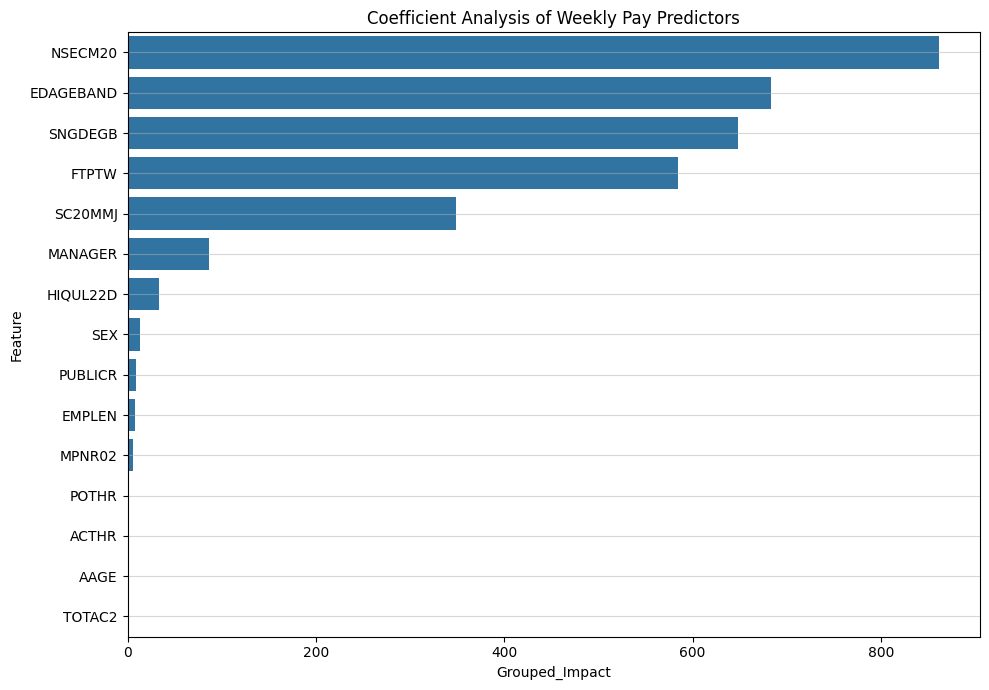

In [150]:
coefficients = pd.DataFrame({
    "Feature": X_wide.columns,
    "Coefficient": regressor.coef_
})

coefficients["Abs_Impact"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="Abs_Impact", ascending=False)

feature_groups = {
    "AAGE": ["AAGE"],
    "ACTHR": ["ACTHR"],
    "EMPLEN": ["EMPLEN"],
    "MPNR02": ["MPNR02"],
    "POTHR": ["POTHR"],
    "TOTAC2": ["TOTAC2"],

    "EDAGEBAND": [col for col in X_wide.columns if col.startswith("EDAGEBAND_")],
    "FTPTW": [col for col in X_wide.columns if col.startswith("FTPTW_")],
    "HIQUL22D": [col for col in X_wide.columns if col.startswith("HIQUL22D_")],
    "MANAGER": [col for col in X_wide.columns if col.startswith("MANAGER_")],
    "NSECM20": [col for col in X_wide.columns if col.startswith("NSECM20_")],
    "PUBLICR": [col for col in X_wide.columns if col.startswith("PUBLICR_")],
    "SC20MMJ": [col for col in X_wide.columns if col.startswith("SC20MMJ_")],
    "SEX": [col for col in X_wide.columns if col.startswith("SEX_")],
    "SNGDEGB": [col for col in X_wide.columns if col.startswith("SNGDEGB_")]
}

grouped = []
for group, cols in feature_groups.items():
    vals = coefficients[coefficients["Feature"].isin(cols)]["Coefficient"]
    grouped.append({
        "Feature": group,
        "Grouped_Impact": vals.abs().sum()
    })

grouped_df = pd.DataFrame(grouped).sort_values(
    by="Grouped_Impact",
    ascending=False
)

print(grouped_df)

plt.figure(figsize=(10, 7))

sns.barplot(data=grouped_df, x="Grouped_Impact", y="Feature")

plt.title("Coefficient Analysis of Weekly Pay Predictors")

plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()

plt.savefig("graphs/coefficient_analysis.png", dpi=300)
plt.show()

In [152]:
# model_columns = ["GRSSWK", "AAGE", "ACTHR", "EDAGEBAND", "FTPTW", "HIQUL22D", "MANAGER", "NSECM20", "POTHR", "PUBLICR", "SC20MMJ", "SNGDEGB" ]
model_columns = ["GRSSWK", "NSECM20", "EDAGEBAND", "SNGDEGB", "FTPTW", "SC20MMJ", "MANAGER", "HIQUL22D", "SEX" ]

df_model = df_combined[model_columns].dropna() # drop where pay is missing
df_model = pd.get_dummies(df_model, columns=["NSECM20", "EDAGEBAND", "SNGDEGB", "FTPTW", "SC20MMJ", "MANAGER", "HIQUL22D"], drop_first=True)

print(f"Regression Model: { len(df_model) } rows / { len(df_model.columns) } columns")


Regression Model: 29537 rows / 66 columns


In [153]:
# Feature (X)
# Target  (y)
X = df_model.drop("GRSSWK", axis=1)
y = df_model["GRSSWK"]

# Split into Training/Test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score:             {r2:.2f}")

Mean Absolute Error: 100.80
R2 Score:             0.50


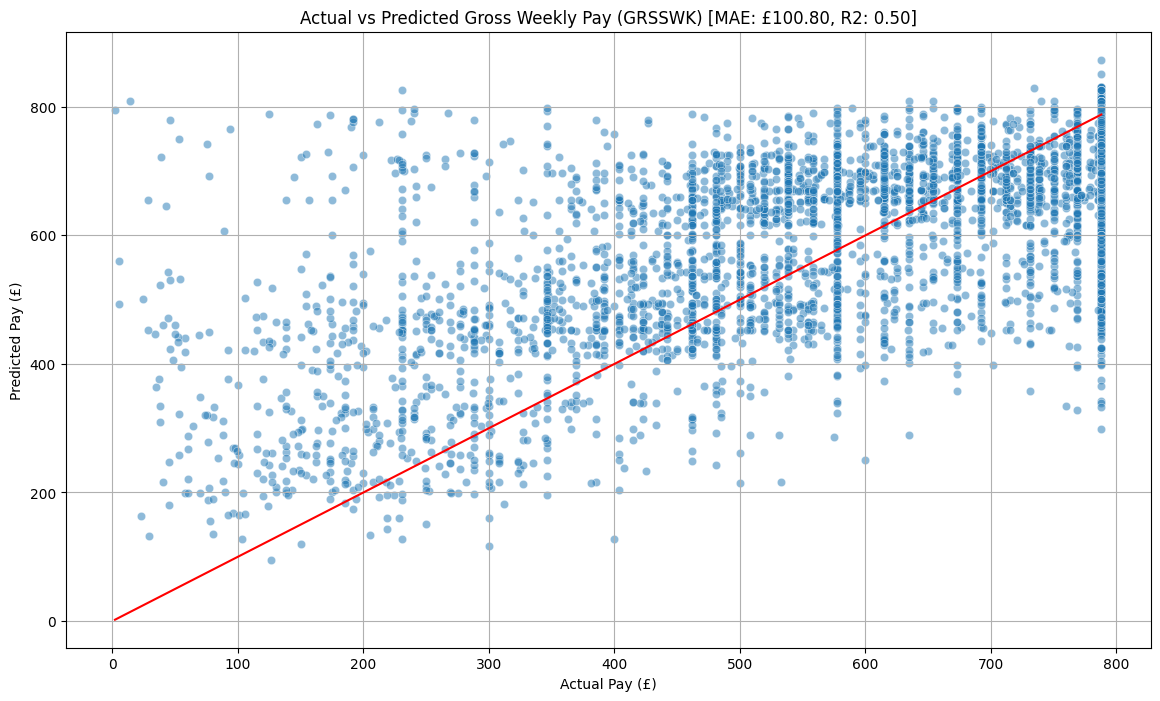

In [154]:
plt.figure(figsize=(14,8))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "red")

plt.title(f"Actual vs Predicted Gross Weekly Pay (GRSSWK) [MAE: £{mae:.2f}, R2: {r2:.2f}]")
plt.xlabel("Actual Pay (£)")
plt.ylabel("Predicted Pay (£)")
plt.grid(True)

plt.savefig("graphs/linear_regression_gross_weekly_pay.png", dpi=300)
plt.show()

### Random Forest Classifier

Predict if someone is employed, unemployed or inactive.

In [198]:
# As I'm predicting employment status, I can't use any features that are dependent on employment
# Instead, focus on demographics/education/health/region
class_columns = ["INECAC05", "AAGE", "EDAGEBAND", "DISEA", "HIQUL_Unified", "MARSTA", "SEX", "TEN1", "FILEYEAR", "COUNTRY", "SATIS", "QUARTER_PERIOD"]
df_classes = df_combined[class_columns].dropna()

In [199]:
def bin_economic_status(val):
    if val in [1.0, 2.0, 3.0, 4.0]:
        return "Employed"
    elif val == 5.0:
        return "Inactive"
    elif 6.0 <= val <= 25.0:
        return "Inactive"
    else:
        return None
    
df_classes["Status_Grouped"] = df_classes["INECAC05"].apply(bin_economic_status)
df_classes = df_classes.dropna(subset=["Status_Grouped"])

In [200]:
X_rf = pd.get_dummies(df_classes.drop(["INECAC05", "Status_Grouped"], axis=1), drop_first=True)
y_rf = df_classes["Status_Grouped"]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

In [201]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

RandomForestClassifier(random_state=42)

In [202]:
y_pred_rf = rf_model.predict(X_test_rf)

print(accuracy_score(y_test_rf, y_pred_rf))
print(classification_report(y_test_rf, y_pred_rf))

0.7668229943864137
              precision    recall  f1-score   support

    Employed       0.82      0.86      0.84     39374
    Inactive       0.63      0.56      0.59     16918

    accuracy                           0.77     56292
   macro avg       0.72      0.71      0.71     56292
weighted avg       0.76      0.77      0.76     56292



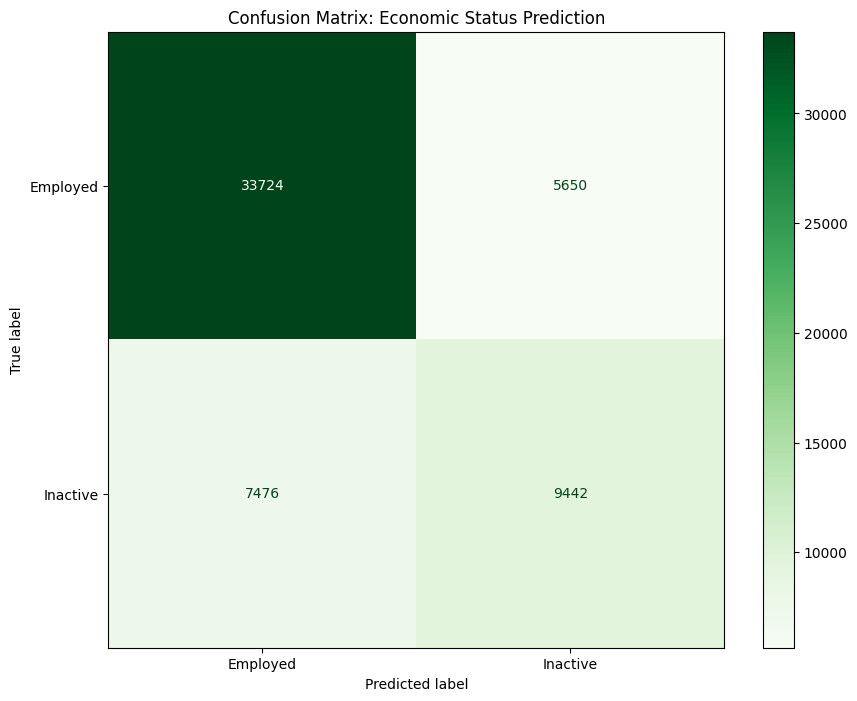

In [203]:
confusion_matrix(y_test_rf, y_pred_rf)
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=rf_model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(values_format="d", cmap="Greens", ax=ax)

plt.title("Confusion Matrix: Economic Status Prediction")
plt.savefig("graphs/confusion_matrix.png", dpi=300)
plt.show()

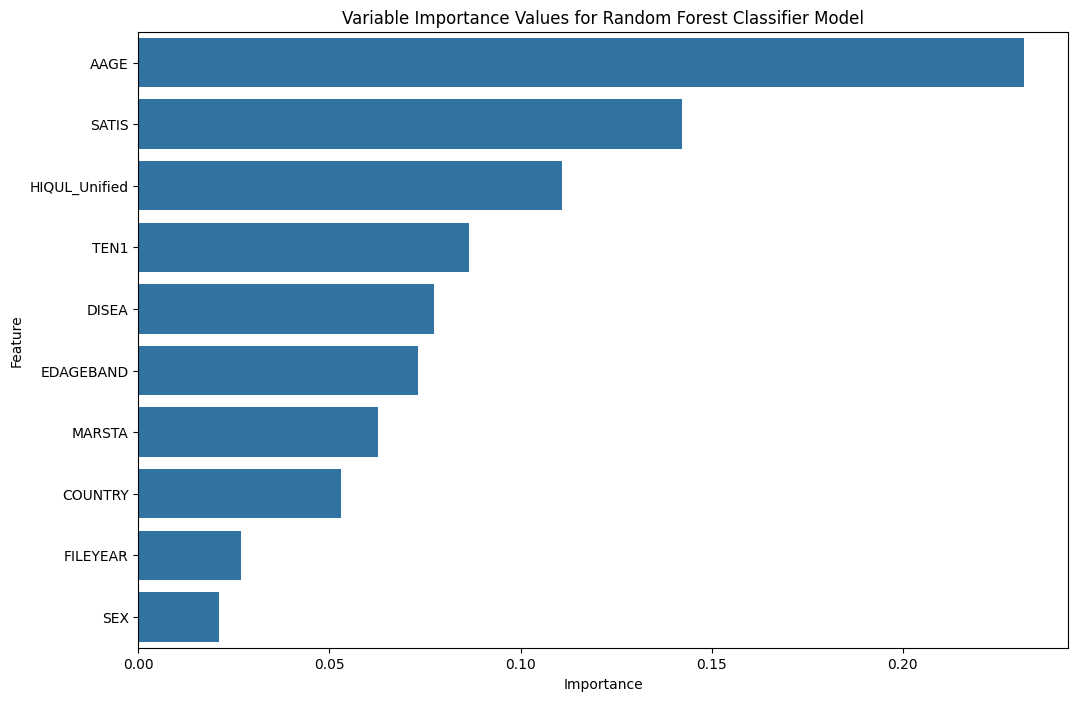

In [214]:
importances = pd.DataFrame({
    "Feature": X_rf.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(data=importances, x="Importance", y="Feature")
plt.title("Variable Importance Values for Random Forest Classifier Model")
plt.savefig("graphs/random_forest_variable_importance.png", dpi=300)
plt.show()

In [205]:
# Five "most important" features for determining if someone is in work, plus the year to determine the affects of the pandemic over time 
focuses = ["AAGE", "SATIS", "HIQUL_Unified", "TEN1", "DISEA", "FILEYEAR", "SEX", "QUARTER_PERIOD"]

In [213]:
df_plot = df_classes[focuses + ["Status_Grouped"]].dropna(subset=["Status_Grouped"]).copy()

aage_map = {
    1.0: "Under 16", 2.0: "16-17", 3.0: "18-19", 4.0: "20-24",
    5.0: "25-29", 6.0: "30-34", 7.0: "35-39", 8.0: "40-44",
    9.0: "45-49", 10.0: "50-54", 11.0: "55-59", 12.0: "60-64",
    13.0: "65-99"
}

hiqual_map = {
    1.0: "Degree", 2.0: "Higher Ed", 3.0: "A-Level", 
    4.0: "GCSE A*-C", 5.0: "Other", 6.0: "None"
}

ten1_map = {
    1.0: "Owned Outright", 2.0: "Mortgage", 3.0: "Shared Ownership", 
    4.0: "Rented", 5.0: "Rent Free", 6.0: "Squatting"
}

disea_map = {
    1.0: "Disabled", 2.0: "Not Disabled"
}

df_plot["Age_Group"] = df_plot["AAGE"].map(aage_map)
df_plot["Highest_Qualifaction"] = df_plot["HIQUL_Unified"].map(hiqual_map)
df_plot["Accommodation"] = df_plot["TEN1"].map(ten1_map)
df_plot["Current_Disability"] = df_plot["DISEA"].map(disea_map)

viz_features = ["Age_Group", "SATIS", "Highest_Qualifaction", "Accommodation", "Current_Disability", "FILEYEAR"]


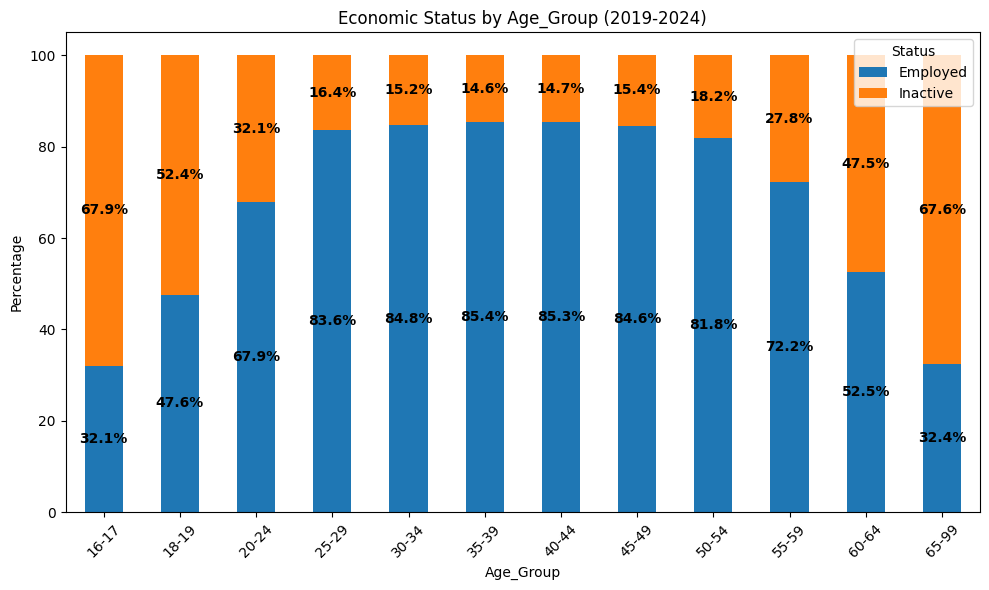

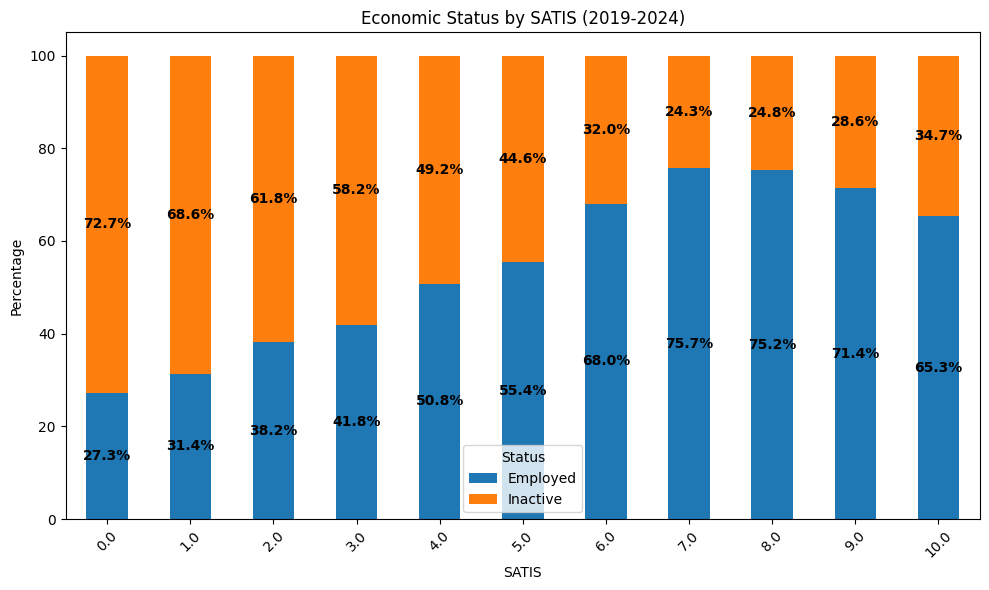

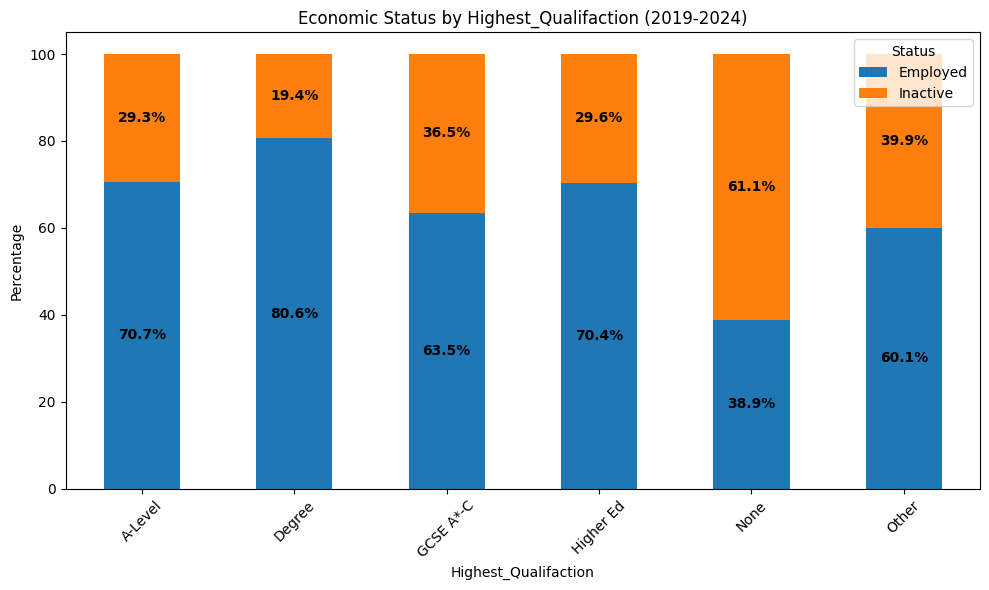

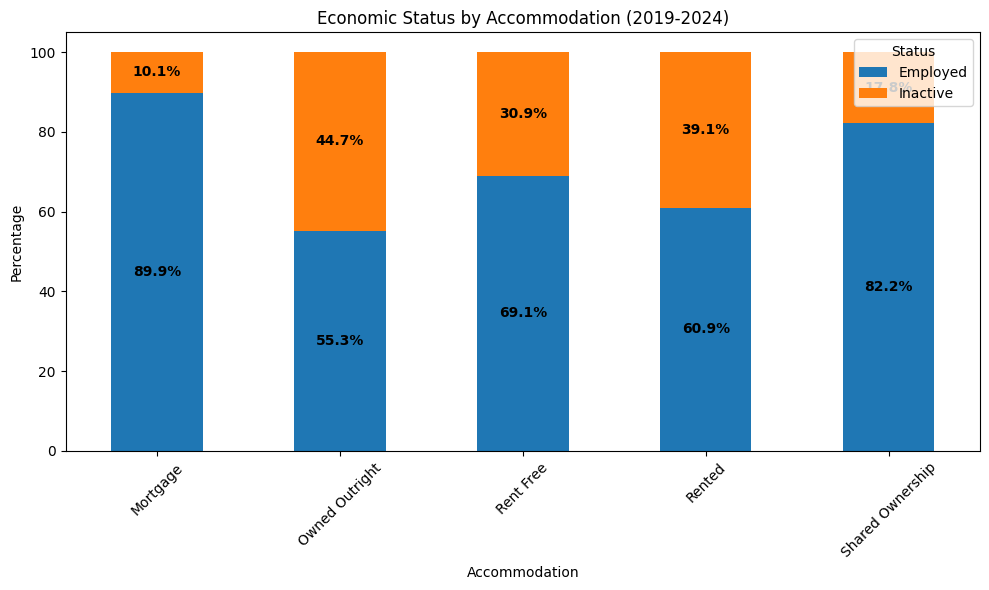

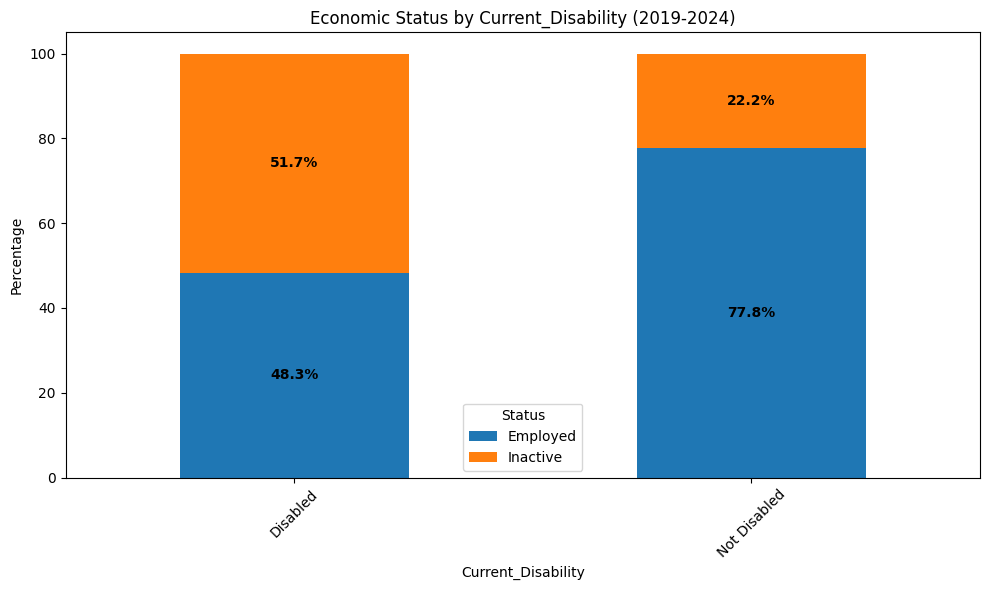

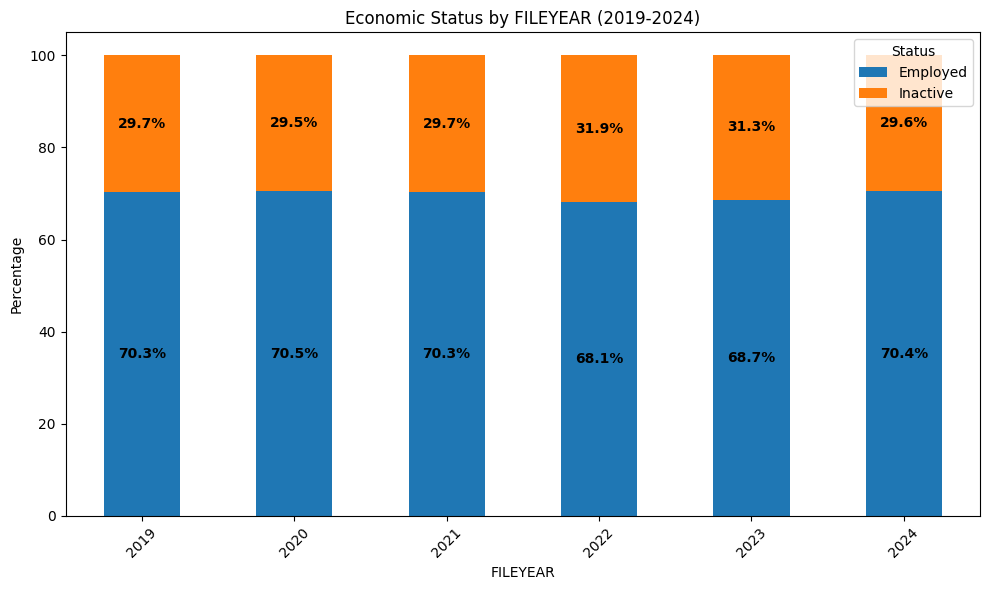

In [215]:
for feature in viz_features:
    data = pd.crosstab(df_plot[feature], df_plot["Status_Grouped"], normalize="index") * 100
    ax = data.plot(kind="bar", stacked=True, figsize=(10, 6))
    
    for patch in ax.patches:
        width, height = patch.get_width(), patch.get_height()
        x, y = patch.get_xy()
        
        ax.text(x + width / 2,
                y + height / 2,
                f"{height:.1f}%",
                horizontalalignment="center",
                verticalalignment="center",
                weight="bold"
        )
    
    plt.title(f"Economic Status by {feature} (2019-2024)")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.legend(title="Status")
    plt.xticks(rotation=45)
    # plt.grid(axis="y")

    plt.tight_layout()
    plt.savefig(f"graphs/rf_interpretation_{feature}.png", dpi=300)
    plt.show()
    

Originally tried catplots to attempt to identify trends over the time period of the pandemic, instead opted for heatmaps which show hotspots of economic inactivity

> https://seaborn.pydata.org/generated/seaborn.catplot.html

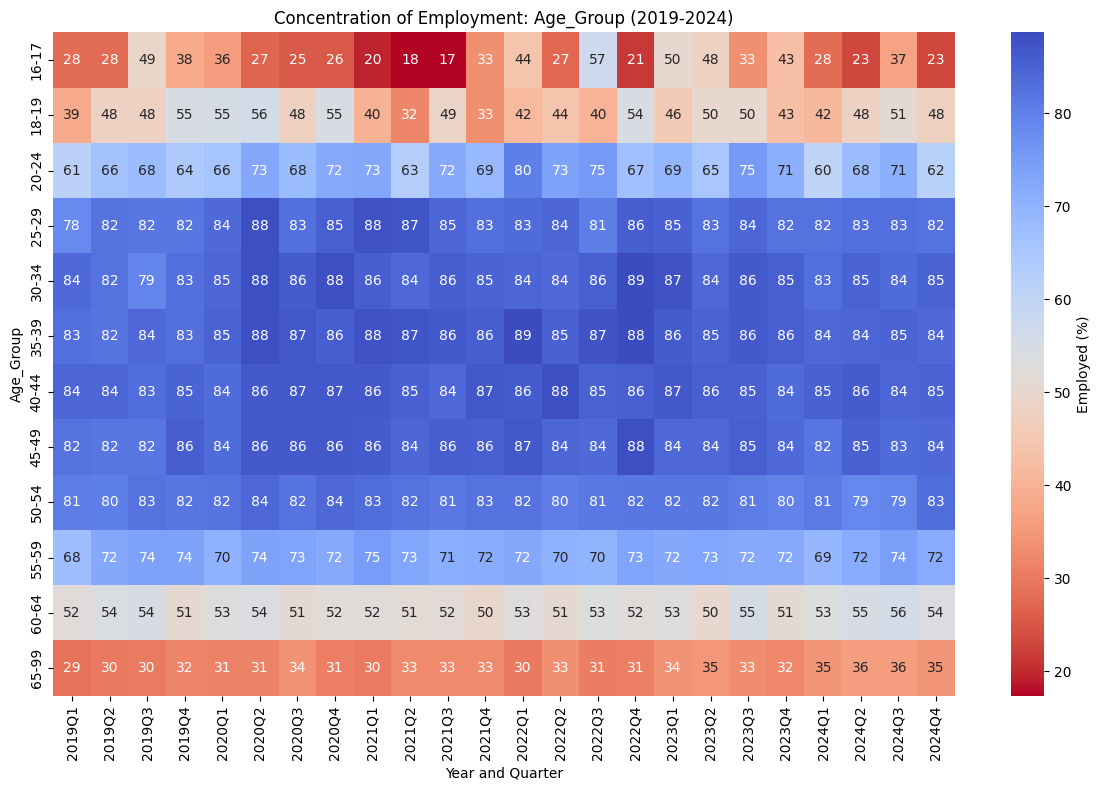

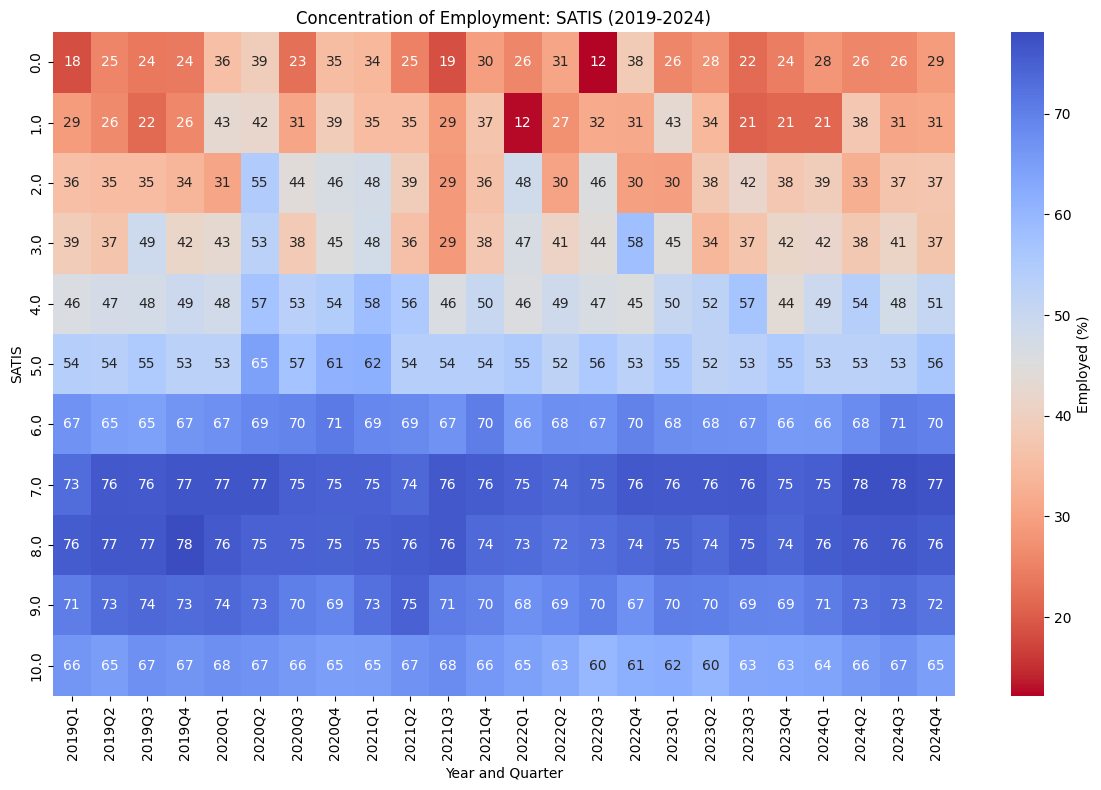

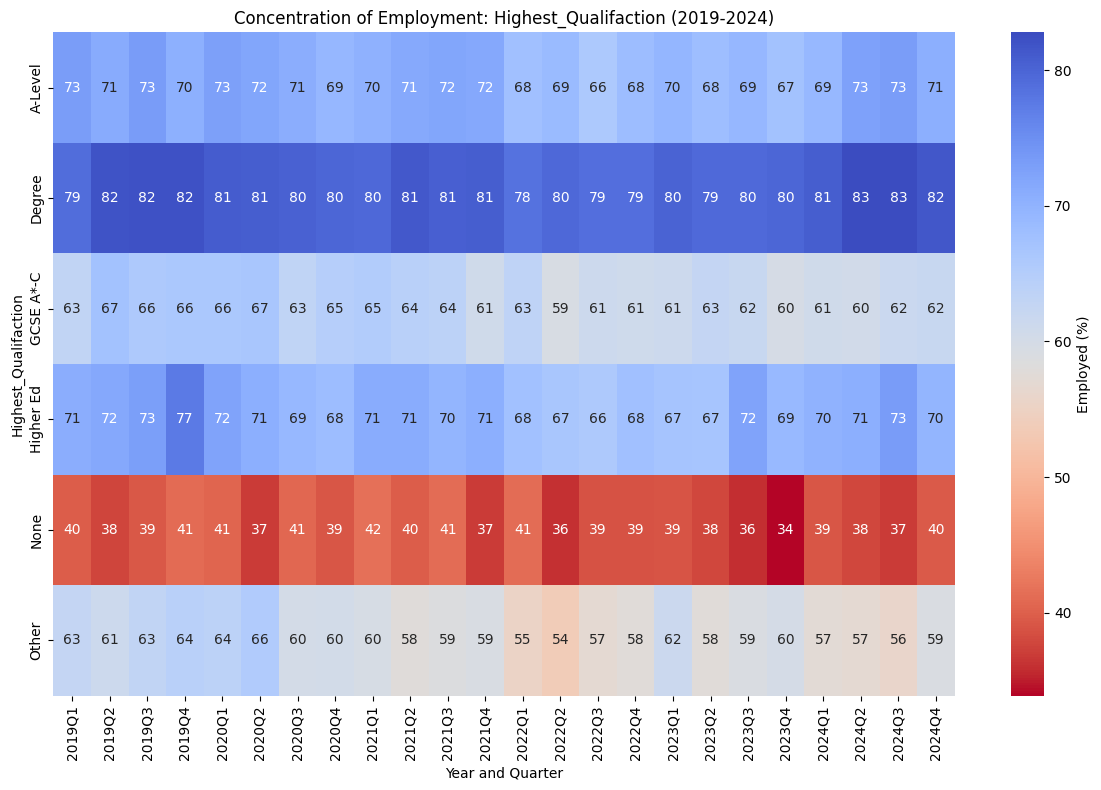

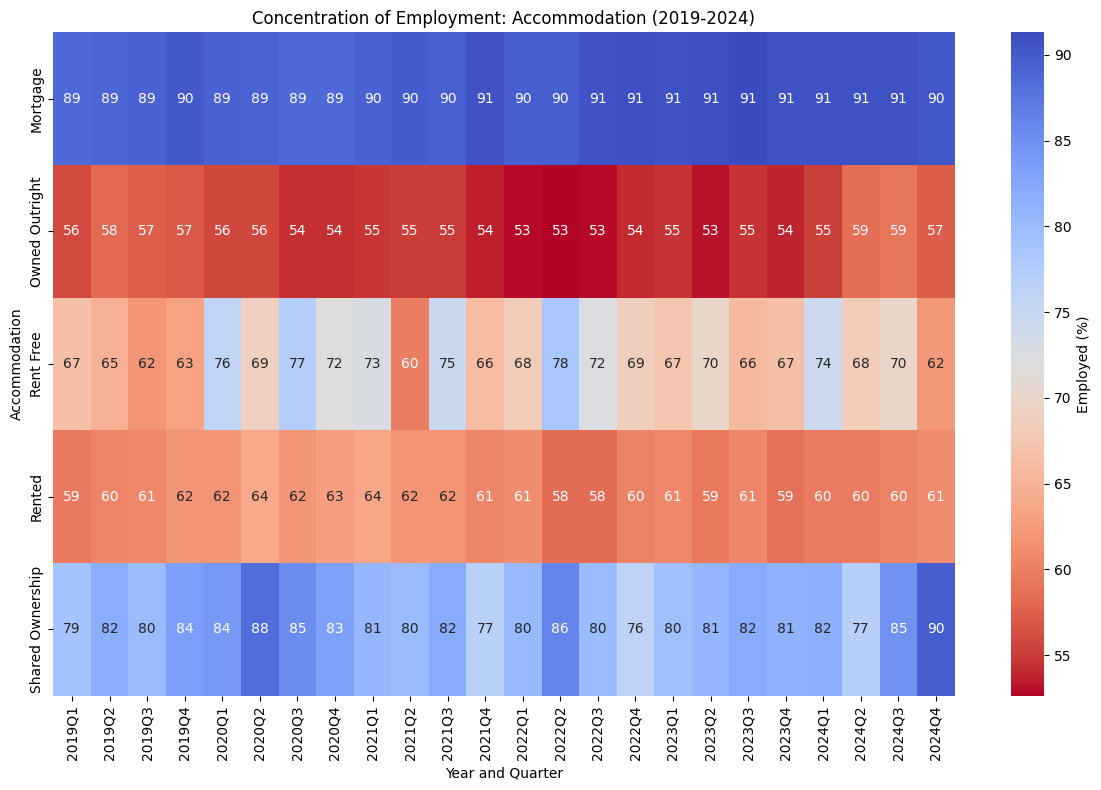

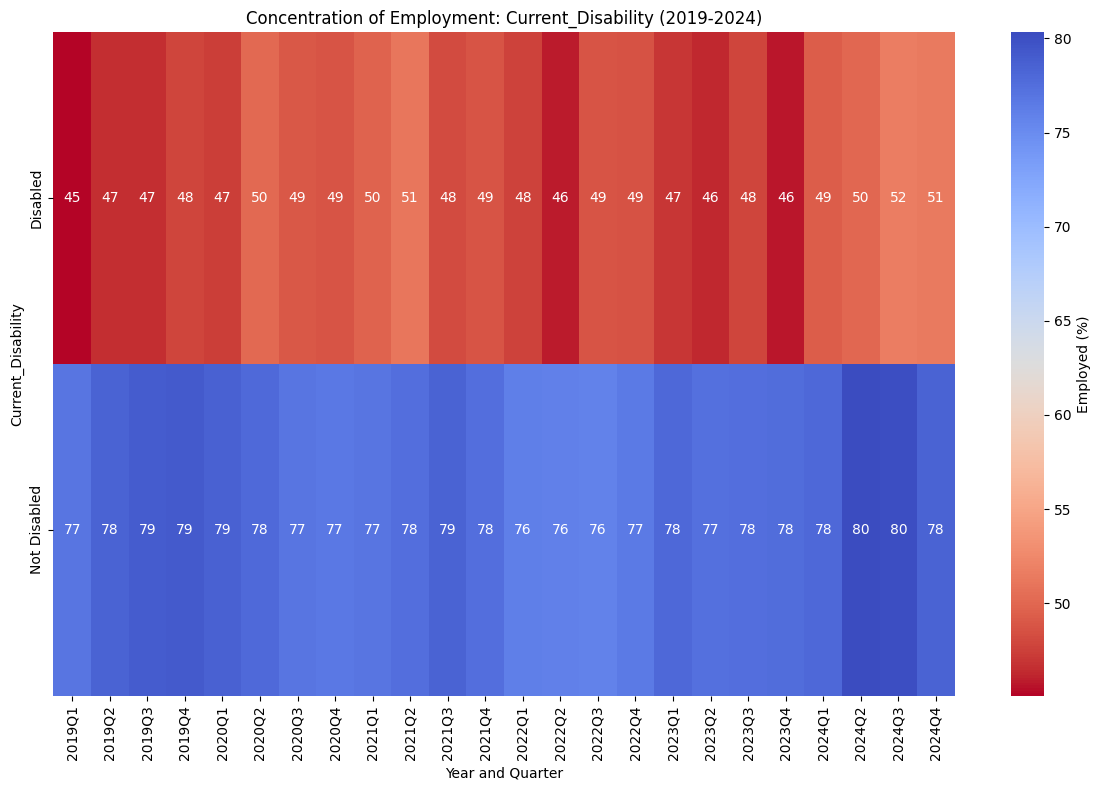


Most Volatile Groups (by Standard Deviation):
          Feature             Group  Mean_Emp_%  Std_Dev    Min    Max  Range
0       Age_Group             16-17       32.52    11.16  17.39  57.14  39.75
13          SATIS               1.0       30.61     7.76  12.50  42.86  30.36
14          SATIS               2.0       38.10     6.86  28.71  54.78  26.07
1       Age_Group             18-19       46.40     6.67  31.88  56.04  24.16
12          SATIS               0.0       26.96     6.46  12.20  39.39  27.20
15          SATIS               3.0       41.68     6.29  28.77  58.02  29.26
2       Age_Group             20-24       68.84     4.97  60.46  80.25  19.80
31  Accommodation         Rent Free       68.96     4.95  59.83  78.33  18.50
16          SATIS               4.0       50.19     4.12  43.85  58.40  14.55
33  Accommodation  Shared Ownership       81.89     3.40  76.19  89.66  13.46

Most Stable Groups (by Standard Deviation):
                 Feature         Group  Mean_Emp_%

In [219]:
all_stats = []

for feature in ["Age_Group", "SATIS", "Highest_Qualifaction", "Accommodation", "Current_Disability"]:
    
    ppt_df = (df_plot.groupby(["QUARTER_PERIOD", feature])["Status_Grouped"]
               .value_counts(normalize=True)
               .mul(100)
               .reset_index(name="percentage"))
    
    heatmap_data = ppt_df[ppt_df["Status_Grouped"] == "Employed"]
    
    pivot_table = heatmap_data.pivot(index=feature, columns="QUARTER_PERIOD", values="percentage")
    
    stats = pd.DataFrame({
        "Feature": feature,
        "Group": pivot_table.index,
        "Mean_Emp_%": pivot_table.mean(axis=1),
        "Std_Dev": pivot_table.std(axis=1),
        "Min": pivot_table.min(axis=1),
        "Max": pivot_table.max(axis=1),
        "Range": pivot_table.max(axis=1) - pivot_table.min(axis=1)
    }).reset_index(drop=True)
    
    all_stats.append(stats)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, cbar_kws={"label": "Employed (%)"}, cmap="coolwarm_r")
    
    plt.title(f"Concentration of Employment: {feature} (2019-2024)")
    plt.xlabel("Year and Quarter")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.savefig(f"graphs/heatmap_{feature}.png", dpi=300)
    plt.show()
    
df_statistical_summary = pd.concat(all_stats, ignore_index=True)
print("\nMost Volatile Groups (by Standard Deviation):")
print(df_statistical_summary.sort_values(by="Std_Dev", ascending=False).head(10).round(2))
print("\nMost Stable Groups (by Standard Deviation):")
print(df_statistical_summary.sort_values(by="Std_Dev", ascending=True).head(10).round(2))